In [16]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
import pickle
import re
import matplotlib.pyplot as plt

# Fungsi untuk membersihkan teks
def clean_text(text):
    text = str(text).lower() # Mengubah ke huruf kecil
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # Menghapus tanda baca
    return text

# Load Data
file_path = 'DataChat.csv'
df = pd.read_csv(file_path)

print("Data Awal:")
print(df.head())

# Pra-pemrosesan data
df['text'] = df['text'].apply(clean_text)

# Hapus duplikat dan data kosong
df_intent = df.drop_duplicates(subset='text').dropna(subset=['intent'])
print("\nData setelah dibersihkan dan duplikat dihapus:")
print(df_intent.head())
print(f"Total data unik: {len(df_intent)}")

# Fungsi Levenshtein Distance untuk menangani typo
def levenshtein_distance(s1, s2):
    if len(s1) < len(s2):
        return levenshtein_distance(s2, s1)
    if len(s2) == 0:
        return len(s1)
    previous_row = range(len(s2) + 1)
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    return previous_row[-1]

# Fungsi untuk memperbaiki typo berdasarkan vocabulary
def correct_typo(text, vocabulary, threshold=1):
    words = text.split()
    corrected_words = []
    for word in words:
        if word in vocabulary or len(word) <= 3:
            corrected_words.append(word)
            continue
        
        best_match = word
        min_distance = float('inf')
        
        for vocab_word in vocabulary:
            if abs(len(word) - len(vocab_word)) > threshold:
                continue
            dist = levenshtein_distance(word, vocab_word)
            if dist < min_distance:
                min_distance = dist
                best_match = vocab_word
        
        if min_distance <= threshold:
            corrected_words.append(best_match)
        else:
            corrected_words.append(word)
    
    return " ".join(corrected_words)

from sklearn.feature_extraction.text import TfidfVectorizer

Data Awal:
                                                text      intent entity_name  \
0  Saya ingin mengetahui jadwal kunjungan hari Se...  cek_jadwal        hari   
1                  Apakah hari Selasa ada kunjungan?  cek_jadwal        hari   
2              Jadwal kunjungan hari Rabu bagaimana?  cek_jadwal        hari   
3                   Apakah hari Kamis bisa membesuk?  cek_jadwal        hari   
4           Apakah hari Jumat ada layanan kunjungan?  cek_jadwal        hari   

  entity_value  
0       Selasa  
1       Selasa  
2         Rabu  
3        Kamis  
4        Jumat  

Data setelah dibersihkan dan duplikat dihapus:
                                                text      intent entity_name  \
0  saya ingin mengetahui jadwal kunjungan hari se...  cek_jadwal        hari   
1                   apakah hari selasa ada kunjungan  cek_jadwal        hari   
2               jadwal kunjungan hari rabu bagaimana  cek_jadwal        hari   
3                    apakah hari kamis

In [17]:
# Tokenisasi dan Padding
texts = df_intent['text'].values
intents = df_intent['intent'].values

tokenizer = Tokenizer(num_words=2000, oov_token='<OOV>')
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

max_length = 20
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

# Label Encoding
label_encoder = LabelEncoder()
encoded_intents = label_encoder.fit_transform(intents)
num_classes = len(label_encoder.classes_)

print(f"Total kelas: {num_classes}")
print(f"Daftar intent: {label_encoder.classes_}")
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(2, 4))
tfidf_features = tfidf_vectorizer.fit_transform(texts).toarray()
tfidf_dim = tfidf_features.shape[1]

print(f"TF-IDF Shape: {tfidf_features.shape}")


Total kelas: 15
Daftar intent: ['barang_bawaan' 'barang_boleh' 'barang_terlarang' 'cara_pendaftaran'
 'cek_jadwal' 'durasi_kunjungan' 'fasilitas' 'ketentuan_pakaian'
 'ketentuan_pengunjung' 'kontak' 'lokasi_layanan' 'pendaftaran_awal'
 'penutup' 'sapaan' 'syarat_kunjungan']
TF-IDF Shape: (214, 2446)


In [18]:
# Arsitektur Model LSTM Hybrid (Embedding + TF-IDF)
from tensorflow.keras.layers import Input, Embedding, LSTM, GlobalMaxPooling1D, Dense, Dropout, Concatenate
from tensorflow.keras.models import Model

# LSTM Input
input_seq = Input(shape=(max_length,))
embedding = Embedding(2000, 64)(input_seq)
lstm_out = LSTM(64, return_sequences=True)(embedding)
pooling = GlobalMaxPooling1D()(lstm_out)

# TF-IDF Input
input_tfidf = Input(shape=(tfidf_dim,))
tfidf_dense = Dense(64, activation='relu')(input_tfidf)

# Merge
merged = Concatenate()([pooling, tfidf_dense])

# Fully Connected
dense1 = Dense(64, activation='relu')(merged)
dropout = Dropout(0.2)(dense1)
output = Dense(num_classes, activation='softmax')(dropout)

# Build Model
model = Model(inputs=[input_seq, input_tfidf], outputs=output)

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_5 (InputLayer)           [(None, 20)]         0           []                               
                                                                                                  
 embedding_2 (Embedding)        (None, 20, 64)       128000      ['input_5[0][0]']                
                                                                                                  
 lstm_2 (LSTM)                  (None, 20, 64)       33024       ['embedding_2[0][0]']            
                                                                                                  
 input_6 (InputLayer)           [(None, 2446)]       0           []                               
                                                                                            

In [19]:
# Pelatihan Model
epochs = 200
history = model.fit(
    [padded_sequences, tfidf_features], 
    encoded_intents, 
    epochs=epochs, 
    verbose=1
)
print("Model selesai dilatih.")

Epoch 1/200
7/7 [==============================] - 2s 9ms/step - loss: 2.6964 - accuracy: 0.1776
Epoch 2/200
7/7 [==============================] - 0s 8ms/step - loss: 2.6301 - accuracy: 0.5607
Epoch 3/200
7/7 [==============================] - 0s 8ms/step - loss: 2.5328 - accuracy: 0.5654
Epoch 4/200
7/7 [==============================] - 0s 8ms/step - loss: 2.3663 - accuracy: 0.5514
Epoch 5/200
7/7 [==============================] - 0s 9ms/step - loss: 2.1819 - accuracy: 0.4486
Epoch 6/200
7/7 [==============================] - 0s 9ms/step - loss: 1.9718 - accuracy: 0.5374
Epoch 7/200
7/7 [==============================] - 0s 8ms/step - loss: 1.7545 - accuracy: 0.6355
Epoch 8/200
7/7 [==============================] - 0s 8ms/step - loss: 1.5072 - accuracy: 0.7243
Epoch 9/200
7/7 [==============================] - 0s 11ms/step - loss: 1.2453 - accuracy: 0.7523
Epoch 10/200
7/7 [==============================] - 0s 10ms/step - loss: 1.0412 - accuracy: 0.7757
Epoch 11/200
7/7 [=========

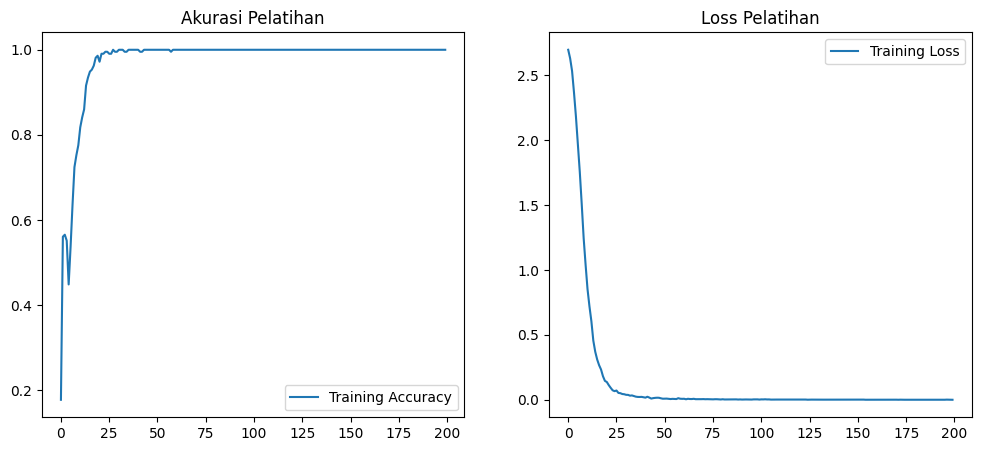

In [20]:
# Visualisasi Hasil Pelatihan
acc = history.history['accuracy']
loss = history.history['loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.title('Akurasi Pelatihan')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.title('Loss Pelatihan')
plt.legend()
plt.show()

In [21]:
# Menyimpan Model dan Artefak menggunakan Pickle
with open('model_chatbot.pickle', 'wb') as handle:
    pickle.dump(model, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('tokenizer.pickle', 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

with open('label_encoder.pickle', 'wb') as handle:
    pickle.dump(label_encoder, handle, protocol=pickle.HIGHEST_PROTOCOL)


with open('tfidf_vectorizer.pickle', 'wb') as handle:
    pickle.dump(tfidf_vectorizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("Model dan artefak (tokenizer, label_encoder) berhasil disimpan dalam format pickle.")

Model dan artefak (tokenizer, label_encoder) berhasil disimpan dalam format pickle.


In [22]:

# Ambil vocabulary dari tokenizer
vocabulary = list(tokenizer.word_index.keys())

import pandas as pd
import numpy as np
import random
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================
# LOAD CSV DATA
# =========================
df_response = pd.read_csv("DataResponse.csv")
df_barang = pd.read_csv("DataBarang.csv")
df_jadwal = pd.read_csv("DataJadwal.csv")
df_fasilitas = pd.read_csv("DataFasilitas.csv")


# =========================
# PREDICT INTENT
# =========================
def predict_intent(text, threshold=0.65):
    cleaned_text = clean_text(text)
    # Perbaiki typo sebelum tokenisasi
    cleaned_text = correct_typo(cleaned_text, vocabulary, threshold=1)

    sequence = tokenizer.texts_to_sequences([cleaned_text])
    tfidf_feat = tfidf_vectorizer.transform([cleaned_text]).toarray()

    if not sequence or not sequence[0]:
        return "unknown", 0.0

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    prediction = model.predict([padded, tfidf_feat], verbose=0)[0]

    class_index = np.argmax(prediction)
    confidence = float(prediction[class_index])

    if confidence < threshold:
        return "fallback", confidence

    intent = label_encoder.classes_[class_index]

    return intent, confidence




# =========================
# GET RESPONSE
# =========================
def get_response(intent, user_input):
    text = user_input.lower().strip()

    # PHASE 1: GLOBAL KEYWORD MATCH (Highest Priority)
    selected_jawaban = None
    best_keyword_len = 0
    
    for _, row in df_response.iterrows():
        kw = str(row["keyword"]).lower()
        if kw != "default" and kw in text:
            if len(kw) > best_keyword_len:
                selected_jawaban = random.choice(row["jawaban"].split("|"))
                best_keyword_len = len(kw)

    if selected_jawaban:
        return selected_jawaban

    # PHASE 2: SPECIALIZED FALLBACK LOGIC
    # CEK DATA JADWAL
    if intent == "cek_jadwal":
        for _, row in df_jadwal.iterrows():
            hari = str(row["hari"]).lower()
            if hari in text:
                if str(row["status"]).lower() == "buka":
                    responses_sched = df_response[(df_response["intent"] == "cek_jadwal") & (df_response["keyword"] == "buka")]["jawaban"].iloc[0].split("|")
                    return random.choice(responses_sched).format(hari=row["hari"], jam_mulai=row["jam_mulai"], jam_selesai=row["jam_selesai"])
                else:
                    responses_sched = df_response[(df_response["intent"] == "cek_jadwal") & (df_response["keyword"] == "tutup")]["jawaban"].iloc[0].split("|")
                    return random.choice(responses_sched).format(hari=row["hari"])

    # CEK DATA BARANG
    if intent in ["barang_terlarang", "barang_bawaan", "barang_boleh"]:
        for _, row in df_barang.iterrows():
            nama_barang = str(row["nama_barang"]).lower()
            if nama_barang in text or any(kata in text for kata in nama_barang.split()):
                return f"Mohon maaf, {row['nama_barang']} {row['status']} dibawa masuk. {row['keterangan']}."

    # CEK DATA FASILITAS
    if intent == "fasilitas":
        for _, row in df_fasilitas.iterrows():
            fasilitas_name = str(row["nama_fasilitas"]).lower()
            if fasilitas_name in text or any(kata in text for kata in fasilitas_name.split()):
                return f"{row['nama_fasilitas']} berada di {row['lokasi']}. {row['keterangan']}."
            
    # PHASE 3: FINAL FALLBACK (Default response from DataResponse.csv)
    res_rows = df_response[df_response["intent"] == intent]
    if res_rows.empty:
        if intent == "unknown": return "Maaf, saya belum memahami pertanyaan Anda."
        res_rows = df_response[df_response["intent"] == "sapaan"]
        
    default_row = res_rows[res_rows["keyword"].str.lower() == "default"]
    if not default_row.empty:
        return random.choice(default_row.iloc[0]["jawaban"].split("|"))
    elif not res_rows.empty:
        return random.choice(res_rows.iloc[0]["jawaban"].split("|"))
        
    return "Maaf, saya belum memahami pertanyaan Anda."

vocabulary = list(tokenizer.word_index.keys())

import pandas as pd
import numpy as np
import random
from tensorflow.keras.preprocessing.sequence import pad_sequences

# =========================
# LOAD CSV DATA
# =========================
df_response = pd.read_csv("DataResponse.csv")
df_barang = pd.read_csv("DataBarang.csv")
df_jadwal = pd.read_csv("DataJadwal.csv")
df_fasilitas = pd.read_csv("DataFasilitas.csv")


# =========================
# PREDICT INTENT
# =========================
def predict_intent(text, threshold=0.65):
    cleaned_text = clean_text(text)
    # Perbaiki typo sebelum tokenisasi
    cleaned_text = correct_typo(cleaned_text, vocabulary, threshold=1)

    sequence = tokenizer.texts_to_sequences([cleaned_text])
    tfidf_feat = tfidf_vectorizer.transform([cleaned_text]).toarray()

    if not sequence or not sequence[0]:
        return "unknown", 0.0

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    prediction = model.predict([padded, tfidf_feat], verbose=0)[0]

    class_index = np.argmax(prediction)
    confidence = float(prediction[class_index])

    if confidence < threshold:
        return "fallback", confidence

    intent = label_encoder.classes_[class_index]

    return intent, confidence




# =========================
# GET RESPONSE
# =========================
def get_response(intent, user_input):
    text = user_input.lower().strip()

    # 1. PRIORITY: Check DataResponse.csv for keyword match
    res_rows = df_response[df_response["intent"] == intent]
    
    selected_jawaban = None
    if not res_rows.empty:
        for _, row in res_rows.iterrows():
            keyword = str(row["keyword"]).lower()
            if keyword != "default" and keyword in text:
                selected_jawaban = random.choice(row["jawaban"].split("|"))
                break

    if selected_jawaban:
        return selected_jawaban

    # 2. FALLBACK: Check specialized data logic (jadwal, barang, fasilitas)
    
    # CEK DATA JADWAL
    if intent == "cek_jadwal":
        for _, row in df_jadwal.iterrows():
            hari = str(row["hari"]).lower()
            if hari in text:
                if str(row["status"]).lower() == "buka":
                    responses_sched = df_response[(df_response["intent"] == "cek_jadwal") & (df_response["keyword"] == "buka")]["jawaban"].iloc[0].split("|")
                    return random.choice(responses_sched).format(hari=row["hari"], jam_mulai=row["jam_mulai"], jam_selesai=row["jam_selesai"])
                else:
                    responses_sched = df_response[(df_response["intent"] == "cek_jadwal") & (df_response["keyword"] == "tutup")]["jawaban"].iloc[0].split("|")
                    return random.choice(responses_sched).format(hari=row["hari"])

    # CEK DATA BARANG
    if intent in ["barang_terlarang", "barang_bawaan", "barang_boleh"]:
        for _, row in df_barang.iterrows():
            nama_barang = str(row["nama_barang"]).lower()
            if nama_barang in text or any(kata in text for kata in nama_barang.split()):
                return f"Mohon maaf, {row['nama_barang']} {row['status']} dibawa masuk. {row['keterangan']}."

    # CEK DATA FASILITAS
    if intent == "fasilitas":
        for _, row in df_fasilitas.iterrows():
            fasilitas = str(row["nama_fasilitas"]).lower()
            if fasilitas in text or any(kata in text for kata in fasilitas.split()):
                return f"{row['nama_fasilitas']} berada di {row['lokasi']}. {row['keterangan']}."
            
    # 3. FINAL FALLBACK: Default response in DataResponse.csv
    if res_rows.empty:
        if intent == "unknown": return "Maaf, saya belum memahami pertanyaan Anda."
        res_rows = df_response[df_response["intent"] == "sapaan"]
        
    default_row = res_rows[res_rows["keyword"].str.lower() == "default"]
    if not default_row.empty:
        return random.choice(default_row.iloc[0]["jawaban"].split("|"))
    elif not res_rows.empty:
        return random.choice(res_rows.iloc[0]["jawaban"].split("|"))
        
    return "Maaf, saya belum memahami pertanyaan Anda."




# =========================
# TEST INTERAKTIF (STABIL)
# =========================
print("=" * 60)
print("         PAS-Assistant Interactive Testing")
print("Ketik 'exit', 'quit', 'keluar', atau kosong")
print("=" * 60)

try:
    while True:
        try:
            user_input = input("\nMasukkan Pertanyaan: ")

            # Antisipasi input None / kosong
            if user_input is None:
                continue

            user_input = user_input.strip()

            # Exit condition
            if user_input.lower() in ["exit", "quit", "keluar", "stop", ""]:
                print("Chatbot dihentikan.")
                break

            # Prediksi
            intent, confidence = predict_intent(user_input)
            response = get_response(intent, user_input)

            # Output lebih rapi
            print("\n" + "-" * 60)
            print(f"Input      : {user_input}")
            print(f"Intent     : {intent}")
            print(f"Confidence : {confidence:.2%}")
            print(f"Respon     : {response}")
            print("-" * 60)

        except Exception as e:
            print(f"Terjadi error: {e}")
            print("Silakan coba pertanyaan lain.")

except KeyboardInterrupt:
    print("\nTes dihentikan oleh user.")

         PAS-Assistant Interactive Testing
Ketik 'exit', 'quit', 'keluar', atau kosong

------------------------------------------------------------
Input      : saya ingin daftar hari ini untuk kunjungan minggu depan, apakah bisa?
Intent     : pendaftaran_awal
Confidence : 100.00%
Respon     : Silakan daftar dari sekarang agar jadwal minggu depan tetap tersedia.
------------------------------------------------------------
Chatbot dihentikan.
